In [1]:
import os
import sys
import warnings

sys.path.insert(0, '..')
sys.path.insert(0, '.')

# os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')

import numpy as np
import matplotlib.pyplot as plt
import numericalunits as nu
from scipy.integrate import simpson

nu.reset_units('SI')
# warnings.filter/warnings('ignore', category=DeprecationWarning)
# warnings.filterwarnings('ignore', category=UserWarning, module='torchquad')
plt.rcParams['text.usetex'] = False
plt.rcParams['figure.dpi'] = 120

BENCHMARK_MASSES_MEV = [10.0, 100.0, 1000.0]
BENCHMARK_FDM = {'heavy': 0, 'light': 2}
DEFAULT_NE_BINS = [1, 2, 3, 4, 5]

from tests.validation_helpers import QEDarkFFAdapter, load_upstream_qcdark, set_dmerates_to_qcdark_astro
from tests.conftest import hdf5_path
from DMeRates.DMeRate import DMeRate

qcdark = load_upstream_qcdark()
plt.rcParams['text.usetex'] = False

In [2]:
sys.path.insert(0, os.path.abspath('../old_for_comparison/QEDark'))
from QEDark3 import QEDark
# from old_for_comparison import QEDark3


CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)


/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_70722/2692239913.py:37: RuntimeWarning: invalid value encountered in divide
  ratio = drde_new_np / drde_old_np


[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.99997519 0.99992683        nan        nan 0.99988613 0.9996644
        nan 0.99974462 0.99985644 0.99976646 0.99969183 0.99945441
 0.99962247 0.99964933 0.99947653 0.99952627 0.99953033 0.99941685
 0.99950307 0.99938268 0.99947069 0.99940465 0.99932603 0.99958303
 0.99934513 0.99925671 0.99929468 0.99914235 0.99931136 0.99923805
 0.9992165  0.999138   0.99919405 0.99916482 0.99913995 0.9992083
 0.99908225 0.99913055 0.99913654 0.99911296 0.99907168 0.99905814
 0.99911629 0.99907869 0.99905341 0.99908641 0.99899661 0.99904884
 0.99905461 0.99908301 0.99899825 0.99897131 0.99900669 0.99894533
 0.99896751 0.99892267 0.99894284 0.99890322 0.99895521 0.99889699
 0.9989301  0.99886479 0.99886018 0.99886323 0.9988199  0.99881066
 0.99874029 0.99877295 0.99880458 0.99876416 0.99874207 0.99872956
 0.99873986 0.99866984 0.99871239 0.99860485 0.99870635 0.998619

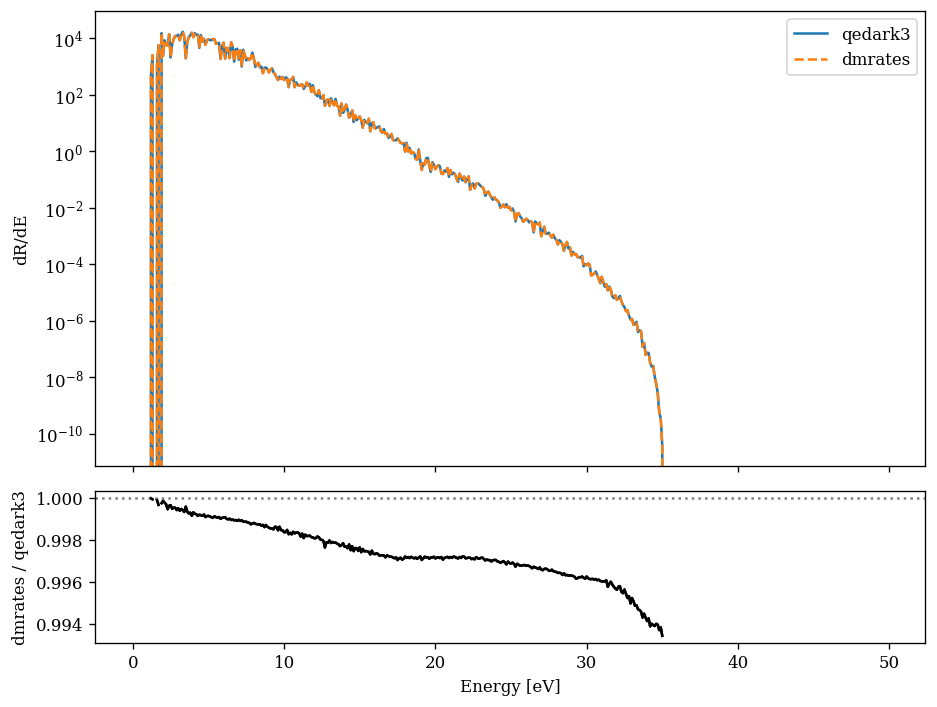

In [7]:
import torch
import matplotlib.pyplot as plt

# test_params 
mX = 10
sigmaE = 1e-36
FDMn = 2
halo_model = 'imb'
DoScreen = False

# Calculate old rate
qedark_old = QEDark()
Ee_array = torch.arange(qedark_old.Emin, qedark_old.Emax, step=qedark_old.dE, device=qedark_old.device)
drde_old = qedark_old.vectorized_dRdE('Si', mX*1e6, Ee_array, FDMn, halo_model, DoScreen)

# Calculate new rate
qedark = DMeRate('Si', form_factor_type='qedark')
energy_eV, drde_new = qedark.calculate_spectrum([mX], halo_model, FDMn, integrate=False, DoScreen=DoScreen)

# Convert old PyTorch tensors to CPU numpy arrays for safe plotting and division
Ee_array_np = Ee_array.detach().cpu().numpy()
drde_old_np = drde_old.detach().cpu().numpy()
drde_new_np = drde_new.flatten()

# Setup subplots (2 rows, 1 column) with the top plot being larger
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top subplot: Main spectra
ax1.plot(Ee_array_np, drde_old_np, label='qedark3')
ax1.plot(energy_eV, drde_new_np, label='dmrates', ls='--')
ax1.set_yscale('log')
ax1.set_ylabel('dR/dE')
ax1.legend()

# Bottom subplot: Ratio
# (Using energy_eV for the x-axis, assuming the bins perfectly align with Ee_array_np)
ratio = drde_new_np / drde_old_np
ax2.plot(energy_eV, ratio, color='k')
ax2.axhline(1.0, color='gray', linestyle=':') # Add a dotted reference line at y=1
ax2.set_ylabel('dmrates / qedark3')
ax2.set_xlabel('Energy [eV]')
ax2.plot(energy_eV, ratio, color='k')
print(ratio)
plt.tight_layout()
plt.show()
plt.close()


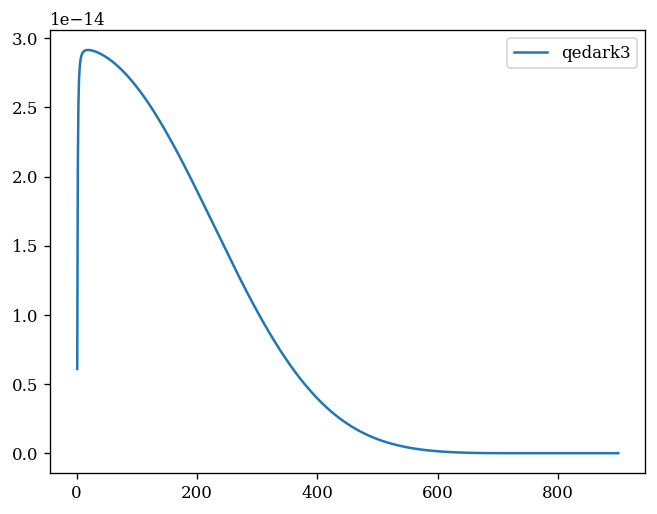

In [24]:
#check eta

q_array_old = torch.arange(1,qedark_old.nq+1,device=qedark_old.device)
etas_old = qedark_old.get_halo_data(mX*1e6,q_array_old,Ee_array,FDMn,halo_model)
etas_old[1,:].shape,q_array_old.shape

plt.plot(q_array_old,etas_old[1,:],label='qedark3')
plt.legend()
plt.show()
plt.close()



In [19]:
qedark_old.rhoX

300000000.0

In [26]:
qedark.rhoX / (nu.eV/(nu.cm**3))

1213.965788872012

In [ ]:
qedark_old.